In [1]:
from dataset import DartsDataset
import numpy as np
from PIL import ImageDraw, Image
import cv2
%load_ext autoreload
%autoreload 2

In [2]:
dirs = [f'3D/scene/rendered/imgs_{i}' for i in range(8)]
dataset = DartsDataset(dirs=dirs, random_rescale=True, random_rotation=True, is_synthetic=True)

In [3]:
def drawbbox(draw, annotation, color):
    x,y,w,h = annotation["bbox"]
    x0, y0, x1, y1 = x, y, x+w, y+h
    draw.rectangle([x0, y0, x1, y1], outline=color)

In [4]:
def draw(image, targets):
    draw = ImageDraw.Draw(image) 
    annotations = targets["annotations"] 
    drawbbox(draw, annotations[0], color="red")
    drawbbox(draw, annotations[1], color="blue")
    drawbbox(draw, annotations[2], color="green")
    drawbbox(draw, annotations[3], color="yellow")

    for annotation in targets["annotations"][4:]:
        drawbbox(draw, annotation, color="orange")

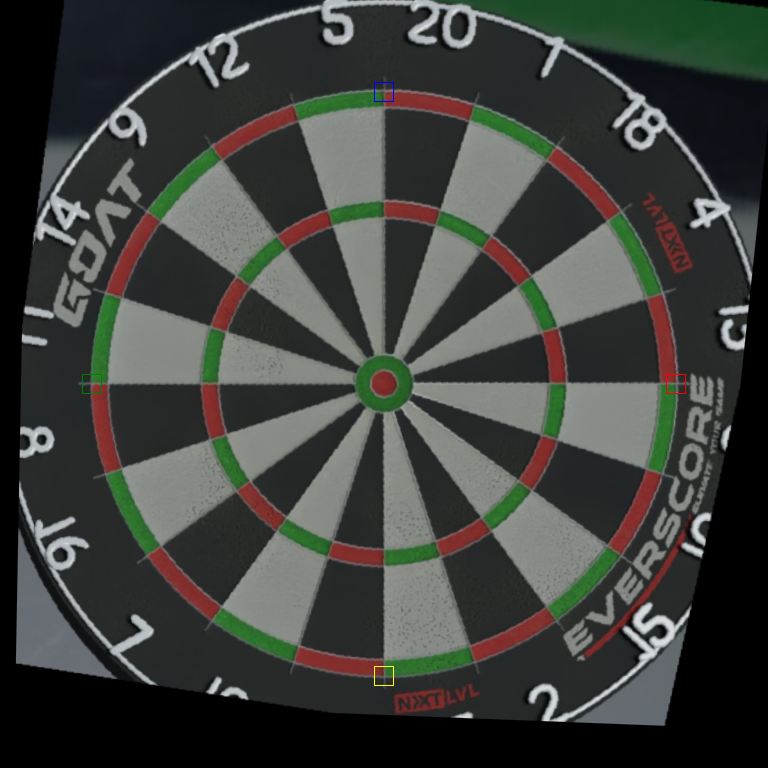

In [5]:
idx = np.random.randint(0, len(dataset))
image, targets, transformed_image, transformed_targets = dataset[idx]
draw(image, targets)
draw(transformed_image, transformed_targets)
transformed_image